# Part1:

In [168]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize
import string

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')


df = pd.read_csv('Final_students_data (1).csv')
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Name,Year,Programming Languages,Certifications,Project Count,Extracurricular Activities,Career Interest,Bio,Cluster
0,Laila Mansour,2,Python; R; SQL,Data Science Professional Certificate (IBM),4,AI Club Mentor,Data Scientist,Laila has always been fascinated by the patter...,1
1,Omar Al-Hassan,4,Java; C++; HTML,CompTIA Security+,5,Cybersecurity Competition Participant,Cybersecurity Analyst,A forth-year student at Princess Sumaya Univer...,2
2,Rania Khoury,1,C; Python; JavaScript,Java Programming (Oracle),3,Peer Programming Tutor,Software Developer,Rania entered the University of Jordan's Compu...,0
3,Khaled Abbas,2,SQL; Python; R,Data Science Professional Certificate (IBM),4,Volunteer Tutor,Data Scientist,Khaled has a knack for translating data into m...,1
4,Nour Husseini,3,Python; Java; SQL,CEH,5,Tech Community Member,Cybersecurity Analyst,"In her Third year at Petra University, Nour is...",2


Load stopwords and Tokenize, remove stop words and punctuation, and apply stemming

In [171]:
ps = PorterStemmer()

stop_words = set(stopwords.words('english'))


df['Cleaned_Bio'] = df['Bio'].apply(lambda x:
    [ps.stem(word) for word in word_tokenize(str(x).lower())
     if word not in stop_words and word not in string.punctuation]
)
df['Cleaned_Bio']

,Cleaned_Bio
0,"[laila, alway, fascin, pattern, data, reveal, ..."
1,"[forth-year, student, princess, sumaya, univer..."
2,"[rania, enter, univers, jordan, 's, comput, sc..."
3,"[khale, knack, translat, data, meaning, insigh..."
4,"[third, year, petra, univers, nour, dive, deep..."
...,...
252,"[reem, first-year, comput, scienc, student, un..."
253,"[yousef, third-year, cyber, secur, student, sp..."
254,"[dalia, second-year, data, scienc, student, al..."
255,"[nabil, senior, comput, scienc, student, psut,..."




*   Apply TF-IDF Vectorization.

*   Join the list of stemmed words back into a single string before applying TF-IDF





*   Convert the TF-IDF matrix to a DataFrame for better visualization








In [174]:
tfidf_vectorizer = TfidfVectorizer()


tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned_Bio'].apply(lambda x: ' '.join(x)))


tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

Print TF-IDF values for each word

In [178]:

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out()) # Use the correct variable to get feature names
tfidf_df

,abeer,academ,action,activ,admin,administr,adnan,advanc,advoc,advocaci,...,year,young,younger,yousef,zaid,zain,zein,zeinab,zeyad,ziad
0,0.0,0.190512,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.067399,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.183198,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.192719,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.066428,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.134115,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
253,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.131120,0.000000,0.0,0.404771,0.0,0.0,0.0,0.0,0.0,0.0
254,0.0,0.000000,0.0,0.233294,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.140335,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
255,0.0,0.000000,0.0,0.000000,0.0,0.383738,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0




*   Static queries
*   make the queries as a dataframe


*   preprecess the queries and apply tokenization, remove stop words, ......, ..
*   Apply TF-IDF vectorization


*   Concatenate the original queries and the TF-IDF DataFrame








In [179]:

queries = [
    "I'm looking for a student with expertise in machine learning.",
    "Seeking a student with strong programming skills.",
    "Need a student who is proficient in data analysis.",
    "Interested in a student who has experience with cloud computing.",
    "Searching for a student with a background in software engineering."
]


df_queries = pd.DataFrame({'query': queries})


def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    stemmed_tokens = [stemmer.stem(word) for word in tokens if word.isalnum() and word not in stop_words]
    return ' '.join(stemmed_tokens)


df_queries['processed_query'] = df_queries['query'].apply(preprocess_text)


tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_queries['processed_query'])


tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())


result_df = pd.concat([df_queries, tfidf_df], axis=1)

result_df

,query,processed_query,analysi,background,cloud,comput,data,engin,experi,expertis,...,machin,need,profici,program,search,seek,skill,softwar,strong,student
0,I'm looking for a student with expertise in ma...,look student expertis machin learn,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.486386,...,0.486386,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.231765
1,Seeking a student with strong programming skills.,seek student strong program skill,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.486386,0.000000,0.486386,0.486386,0.000000,0.486386,0.231765
2,Need a student who is proficient in data analy...,need student profici data analysi,0.486386,0.000000,0.000000,0.000000,0.486386,0.000000,0.000000,0.000000,...,0.000000,0.486386,0.486386,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.231765
3,Interested in a student who has experience wit...,interest student experi cloud comput,0.000000,0.000000,0.486386,0.486386,0.000000,0.000000,0.486386,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.231765
4,Searching for a student with a background in s...,search student background softwar engin,0.000000,0.486386,0.000000,0.000000,0.000000,0.486386,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.486386,0.000000,0.000000,0.486386,0.000000,0.231765




*   Apply TF-IDF vectorization to the queries
*   Convert the TF-IDF matrix to a DataFrame

*   Calculate cosine similarity
*   Calculate Euclidean distance





In [180]:

tfidf_matrix_queries = tfidf_vectorizer.transform(df_queries['processed_query'])


tfidf_queries_df = pd.DataFrame(tfidf_matrix_queries.toarray(), columns=tfidf_vectorizer.get_feature_names_out())


cosine_similarities = cosine_similarity(tfidf_matrix_queries, tfidf_matrix)
df_queries['cosine_similarity'] = list(cosine_similarities)


euclidean_distances_matrix = euclidean_distances(tfidf_matrix_queries, tfidf_matrix)
df_queries['euclidean_distance'] = list(euclidean_distances_matrix)


df_queries

,query,processed_query,cosine_similarity,euclidean_distance
0,I'm looking for a student with expertise in ma...,look student expertis machin learn,"[1.0, 0.05371522955704774, 0.05371522955704774...","[0.0, 1.3757069240524686, 1.3757069240524686, ..."
1,Seeking a student with strong programming skills.,seek student strong program skill,"[0.05371522955704774, 1.0, 0.05371522955704774...","[1.3757069240524686, 0.0, 1.3757069240524686, ..."
2,Need a student who is proficient in data analy...,need student profici data analysi,"[0.05371522955704774, 0.05371522955704774, 1.0...","[1.3757069240524686, 1.3757069240524686, 0.0, ..."
3,Interested in a student who has experience wit...,interest student experi cloud comput,"[0.05371522955704774, 0.05371522955704774, 0.0...","[1.3757069240524686, 1.3757069240524686, 1.375..."
4,Searching for a student with a background in s...,search student background softwar engin,"[0.05371522955704774, 0.05371522955704774, 0.0...","[1.3757069240524686, 1.3757069240524686, 1.375..."


In [181]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_matrix_bios = tfidf_vectorizer.fit_transform(df['Cleaned_Bio'].apply(lambda x: ' '.join(x)))


tfidf_matrix_queries = tfidf_vectorizer.transform(df_queries['processed_query'])


cosine_similarities = cosine_similarity(tfidf_matrix_queries, tfidf_matrix_bios)


for idx, query in enumerate(queries):
    print(f"Query: {query}")
    related_bios = [(df['Bio'].iloc[i], cosine_similarities[idx][i]) for i in range(len(df)) if cosine_similarities[idx][i] > 0]
    related_bios.sort(key=lambda x: x[1], reverse=True)
    for bio, similarity in related_bios:
        print(f"- {bio} (Cosine Similarity: {similarity:.4f})")


Query: I'm looking for a student with expertise in machine learning.
- Reem is a second-year Data Science student at Princess Sumaya University for Technology, interested in machine learning. She is part of the Data Science Ambassadors and wants to become a Machine Learning Engineer. (Cosine Similarity: 0.2850)
- Rami, a senior at Petra University, has a strong foundation in data science and machine learning. As an AI research assistant, he explores cutting-edge AI applications and plans to use his knowledge to build machine learning models as a Machine Learning Engineer. (Cosine Similarity: 0.2833)
- Mohammad is a senior at Princess Sumaya University for Technology, specializing in machine learning and data science. He assists in AI research projects and is working on developing machine learning models. Mohammad aims to work as a Machine Learning Engineer, improving predictive analytics in the healthcare industry. (Cosine Similarity: 0.2734)
- Adnan is a second-year Data Science stude

In [182]:
euclidean_dist = euclidean_distances(tfidf_matrix_queries, tfidf_matrix_bios)


for idx, query in enumerate(queries):
    print(f"Query: {query}")
    related_bios = [(df['Bio'].iloc[i], euclidean_dist[idx][i]) for i in range(len(df)) if euclidean_dist[idx][i] > 0]
    related_bios.sort(key=lambda x: x[1])
    for bio, distance in related_bios:
        print(f"- {bio} (Euclidean Distance: {distance:.4f})")


Query: I'm looking for a student with expertise in machine learning.
- Reem is a second-year Data Science student at Princess Sumaya University for Technology, interested in machine learning. She is part of the Data Science Ambassadors and wants to become a Machine Learning Engineer. (Euclidean Distance: 1.1958)
- Rami, a senior at Petra University, has a strong foundation in data science and machine learning. As an AI research assistant, he explores cutting-edge AI applications and plans to use his knowledge to build machine learning models as a Machine Learning Engineer. (Euclidean Distance: 1.1973)
- Mohammad is a senior at Princess Sumaya University for Technology, specializing in machine learning and data science. He assists in AI research projects and is working on developing machine learning models. Mohammad aims to work as a Machine Learning Engineer, improving predictive analytics in the healthcare industry. (Euclidean Distance: 1.2055)
- Adnan is a second-year Data Science st

# D Criteria



*   Calculate Euclidean distance
*   Statistical threshold calculation using mean and standard deviation



In [185]:
def get_relevant_bios(query):
    processed_query = preprocess_text(query)
    tfidf_matrix_query = tfidf_vectorizer.transform([processed_query])


    euclidean_dist = euclidean_distances(tfidf_matrix_query, tfidf_matrix_bios)[0]


    mean_distance = np.mean(euclidean_dist)
    std_dev = np.std(euclidean_dist)
    threshold = mean_distance - std_dev

    relevant_bios = [(df['Bio'].iloc[i], euclidean_dist[i]) for i in range(len(df)) if euclidean_dist[i] <= threshold]
    relevant_bios.sort(key=lambda x: x[1])  

    print(f"Query: {query}")
    if relevant_bios:
        for bio, distance in relevant_bios:
            print(f"- {bio} (Euclidean Distance: {distance:.4f})")
    else:
        print("No relevant bios found based on the statistical threshold.")


print("\n### Single Word Query ###")
single_word_query = input("Enter a single word query: ")
get_relevant_bios(single_word_query)

print("\n### Two Words Query ###")
two_words_query = input("Enter a two words query: ")
get_relevant_bios(two_words_query)

print("\n### Multiple Words Query ###")
multiple_words_query = input("Enter multiple words query: ")
get_relevant_bios(multiple_words_query)

print("\n### Full Sentence Query ###")
sentence_query = input("Enter a sentence query: ")
get_relevant_bios(sentence_query)


### Single Word Query ###
Enter a single word query: python
Query: python
- Basil, a Computer Science student at the University of Jordan, is highly skilled in Java and Python. He has contributed to several open-source projects and aims to work as a Software Engineer, creating innovative solutions to everyday challenges. (Euclidean Distance: 1.2441)
- Lina is a third-year Data Science student at Princess Sumaya University for Technology, who is already excelling in Python and SQL. As a member of the Data Science Club, she is eager to learn and contribute to solving complex data problems. Lina aspires to work as a Data Scientist, specializing in AI-driven analytics. (Euclidean Distance: 1.2619)
- Maya, a freshman at Al Hussein Technical University, has already made a name for herself with her tech blog, where she shares her coding insights. She is particularly passionate about JavaScript and Python and dreams of becoming a Software Developer who specializes in building intuitive web ap

# Part2:

Enter the student's name: Reem Fathi


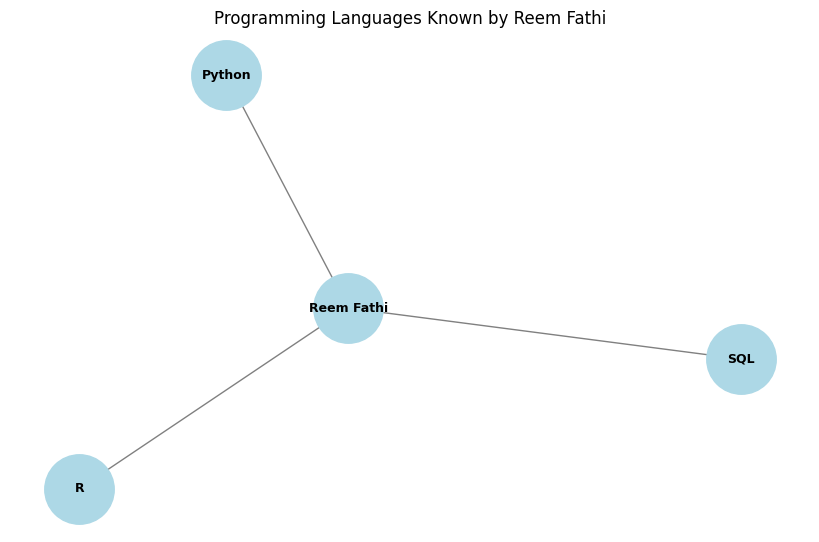

In [151]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

student_name = input("Enter the student's name: ")

# Check if the student exists in the DataFrame
if student_name in students_data['Name'].values:
    student_data = students_data[students_data['Name'] == student_name].iloc[0]
    programming_languages = student_data['Programming Languages'].split('; ')

    G = nx.Graph()
    G.add_node(student_name)

    for lang in programming_languages:
        G.add_node(lang)
        G.add_edge(student_name, lang)

    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2500, font_size=9, font_weight='bold')
    plt.title('Programming Languages Known by ' + student_name)
    plt.show()
else:
    print(f"Student '{student_name}' not found in the dataset.")

Enter the certificate name: IBM


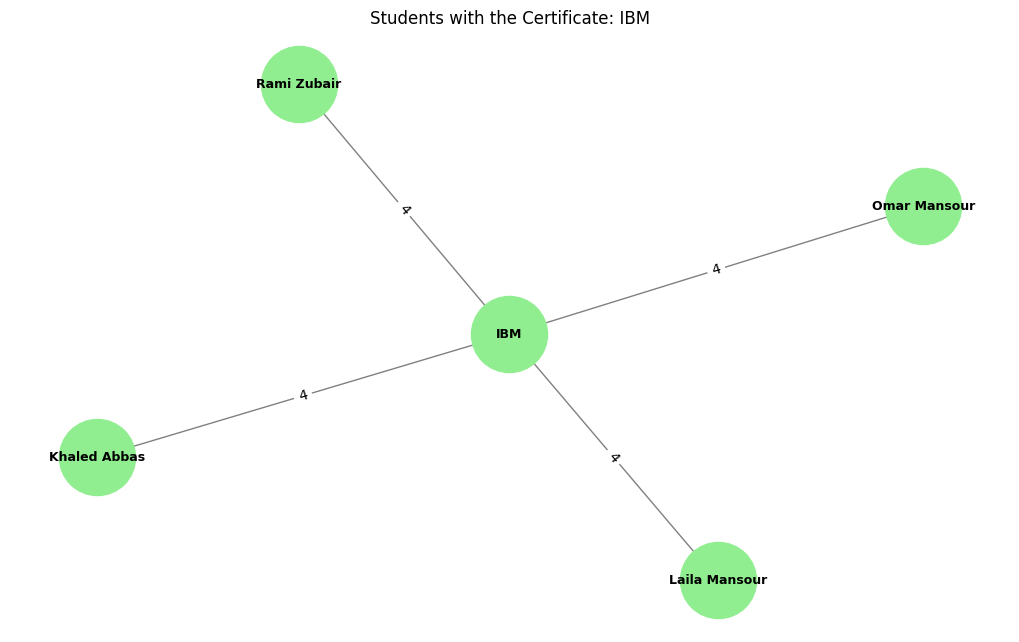

In [152]:


def plot_certificate_graph(certificate_name):
    filtered_data = students_data[students_data['Certifications'].str.contains(certificate_name, na=False)]
    if filtered_data.empty:
        print("No students with this certificate found.")
        return

    G_cert = nx.Graph()
    G_cert.add_node(certificate_name)

    for index, row in filtered_data.iterrows():
        student_name = row['Name']
        project_count = row['Project Count']
        G_cert.add_node(student_name)
        G_cert.add_edge(certificate_name, student_name, weight=project_count)

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G_cert)
    edge_labels = {(n1, n2): d['weight'] for n1, n2, d in G_cert.edges(data=True)}
    nx.draw(G_cert, pos, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=3000, font_size=9, font_weight='bold')
    nx.draw_networkx_edge_labels(G_cert, pos, edge_labels=edge_labels)
    plt.title('Students with the Certificate: ' + certificate_name)
    plt.show()

certificate_input = input("Enter the certificate name: ")
plot_certificate_graph(certificate_input)


In [ ]:
print('احلى تحية لسند هرم الاسنان')

احلى تحية لسند هرم الاسنان


# Part3:

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans, HDBSCAN, MeanShift, AffinityPropagation, MiniBatchKMeans, AgglomerativeClustering, BisectingKMeans, DBSCAN, HDBSCAN, OPTICS
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import adjusted_rand_score, adjusted_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

In [204]:

df = pd.read_csv('Final_students_data (1).csv')

# Create a new dataframe for preprocessing
df_preprocessed = df.copy()


# Label encoding categorical variables
label_encoders = {}
categorical_columns = ['Programming Languages', 'Certifications', 'Extracurricular Activities', 'Career Interest', 'Bio']

for col in categorical_columns:
    le = LabelEncoder()
    df_preprocessed[col] = le.fit_transform(df_preprocessed[col])
    label_encoders[col] = le

# Standardizing numerical variables
scaler = StandardScaler()
numerical_columns = ['Year', 'Project Count', 'Programming Languages', 'Certifications', 'Extracurricular Activities', 'Career Interest', 'Bio']
df_preprocessed[numerical_columns] = scaler.fit_transform(df_preprocessed[numerical_columns])

In [205]:
labels = df['Cluster']
df = df.drop('Cluster', axis=1)

In [206]:
pca = PCA(n_components=0.9)
df_pca = pca.fit_transform(df_preprocessed[numerical_columns])



df = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(df_pca.shape[1])])

print(df.head())


        PC1       PC2       PC3       PC4       PC5
0  0.622569 -1.185614 -1.123195 -0.568599 -0.473434
1  2.022850  1.959906 -0.301034 -0.179743 -2.250176
2 -3.171311  0.235212  0.805581 -0.129793 -0.787116
3  0.073986  0.598974 -0.619416 -0.314294  1.913938
4  1.803993  1.534627  0.082151 -0.513084  0.911691


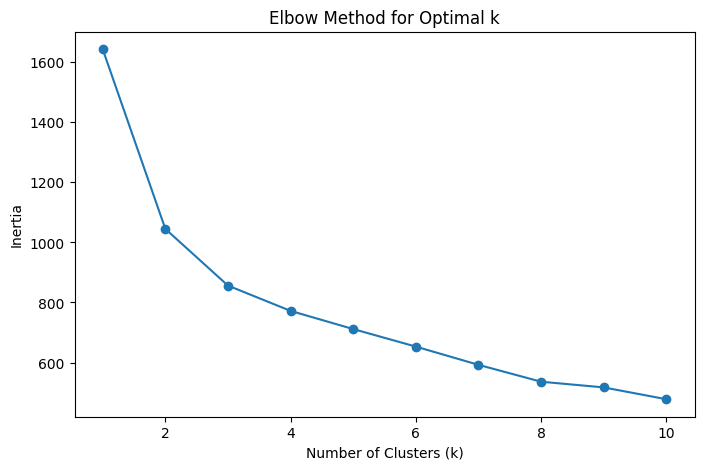

In [207]:
inertia = []

for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(df_pca)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [208]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3).fit(df)
clusters=kmeans.predict(df)
print("Kmeans Clustering trained.")
ARI_Score = adjusted_rand_score(labels, clusters)
print("ARI score: ", ARI_Score)
AMI_Score = adjusted_mutual_info_score(labels,clusters)
print("AMI score: ", AMI_Score)
sil_score = silhouette_score(df, clusters)
print("Silhouette score: ", sil_score)
CH_score = calinski_harabasz_score(df, clusters)
print("CH score: ", CH_score)
DB_index = davies_bouldin_score(df, clusters)
print("DB index: ", DB_index)

print(clusters)


Kmeans Clustering trained.
ARI score:  0.8155584473561214
AMI score:  0.804906630528526
Silhouette score:  0.2682137613927507
CH score:  116.5699025013901
DB index:  1.4980789156119467
[0 2 1 0 2 1 0 2 1 0 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 0 2
 1 0 2 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 0 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0
 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 0 0 2
 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 0 2 1 0 2 1 0 2 1 0 2
 1 0 2 1 0 2 1 0 2 1 0 0 2 1 0 2 1 0 2 1 0 0 1 0 2 1 0 2 1 0 2 1 0 2 1 0 1
 0 2 1 0 2 1 0 2 1 0 2 0 0 0 1 0 2 1 0 2 0 0 2 0 1 0 2 1 0 2 1 0 0 1 0 2 1
 0 2 0 0 0 1 0 2 0 0 2 0 1 2 0 0 0 0 1 2 0 1 2 0 0 2 0 1 0 0 1 0 0 1 2]


In [209]:
dbscan = DBSCAN()
clusters_dbscan = dbscan.fit_predict(df)
print(clusters_dbscan)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1  0 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1  0 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1]


In [210]:
hdbscan = HDBSCAN()
clusters_hdbscan = hdbscan.fit_predict(df)
print(clusters_hdbscan)

[ 2  0  1 -1  2  1  2  2  1 -1  2  0  1  2  2  1  2  2  1  2 -1 -1  2  0
  1  2  2  1  2  2  1  2  3  1  2  2 -1  1  2 -1  2  2  1  2  2 -1  2  2
 -1  2  0  1  2 -1  1  2  2  1  2  2  1  2  2 -1  2  0  1  2  2  1  2 -1
  1  2  2  1  2 -1  1  2  2  1  2  2 -1  2  2 -1  2  3 -1  2  2  1  2  2
  1  2  2 -1  2  2  1  2  2  1  2  2 -1  2 -1  1 -1  2  1  2  2  1  2  2
 -1  2 -1  1  2  2  1  2  2  1  2  2  1  2  2 -1  2  2 -1  1  2  2  1  2
 -1  1  2  2  1  2  2  1  2 -1  1  2  2  1  2  2 -1 -1  2  3  1  2  2 -1
  2  2  1  2  3  1  2  2  1  2  2 -1  2  2  1  2  1  2 -1 -1  2  2  1  2
 -1  1  2  2 -1  2  2  1  2  2 -1  2  2 -1  2 -1 -1  1  2  2 -1  2  2 -1
  2 -1  1  2  2  1 -1  2 -1  2  2  1  2 -1 -1  2  2  2 -1  3  2 -1  2  2
  1  2  2 -1  2  2 -1  2 -1  1  2  2  1  2  2  1  2]


In [211]:
optics = OPTICS()
clusters_optics = optics.fit_predict(df)
print(clusters_optics)

[ 0 10 -1 -1 -1 -1  1 -1 -1 -1 -1 10 -1 -1  5 -1 -1  7 -1  3  8 -1  0 10
 -1 -1 -1 -1 -1 -1 -1 -1  8 -1 -1  4 -1 -1 -1 -1  2 -1 -1 -1  6 -1  1 -1
 -1 -1 10 -1 -1 -1 -1 -1 -1 -1  1  7 -1  2  5 -1  0 10  9  2 -1 -1  0 -1
 -1  1  6 -1  3 -1 -1  1 -1 -1  0  6 -1 -1  7 -1  4  8 -1 -1 -1  9 -1 -1
 -1 -1 -1 -1 -1 -1  9 -1  7 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1  6 -1 -1  7
 -1  3  8 -1 -1  6  9  2  6  9 -1  6 -1 -1  5 -1  2 -1 -1 -1  2  6 -1  2
 -1 -1  4 -1 -1  1 -1 -1 -1 -1 -1  4  5 -1 -1 -1 -1 -1  2  8  9 -1 -1 -1
  3 -1 -1  2  8 -1  2  6 -1  2 -1 -1  3 -1 -1  4 -1  1  8 -1 -1  7  9 -1
 -1  9  3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  4 -1 -1 -1  2 -1 -1  2 -1 -1
  4 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  3 -1 -1  3 -1  1 -1  8 -1 -1 -1 -1
  9 -1  2 -1 -1 -1 -1  5 -1 -1 -1  0  9 -1  2 -1 -1]


In [212]:
bisect_kmeans = BisectingKMeans(n_clusters=3)
clusters_bisect_kmeans = bisect_kmeans.fit_predict(df)
print(clusters_bisect_kmeans)

[1 2 0 1 2 0 1 2 0 1 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 1 2
 0 1 2 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 1 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1
 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 1 1 2
 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 1 2 0 1 2 0 1 2 0 1 2
 0 1 2 0 1 2 0 1 2 0 1 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 0
 1 2 0 1 2 0 1 2 0 1 2 1 1 1 0 1 2 0 1 2 0 1 2 1 0 1 2 0 1 2 0 1 1 0 1 2 0
 1 2 1 1 1 0 1 2 1 1 2 1 0 2 1 1 2 1 0 2 1 0 2 1 1 2 1 0 1 1 0 2 1 0 2]


In [213]:
  agglomerative = AgglomerativeClustering(n_clusters=3)
  clusters_agglo = agglomerative.fit_predict(df)
  print(clusters_agglo)

[0 2 1 0 2 1 0 2 1 0 0 2 1 0 2 1 0 2 1 0 0 1 0 2 1 0 2 1 0 2 1 0 0 1 0 0 2
 1 0 2 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 0 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0
 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 0 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2 1 0 2
 1 0 2 1 0 2 1 0 2 1 0 0 1 0 2 1 0 2 1 0 2 1 0 2 1 0 0 0 1 0 2 1 0 0 1 0 0
 1 0 2 1 0 2 1 0 2 1 0 0 0 1 0 0 1 0 2 1 0 0 1 0 0 1 0 2 1 0 2 1 0 2 1 0 1
 0 0 1 0 2 1 0 0 1 0 2 1 0 0 1 0 2 1 0 2 1 0 0 0 1 0 2 1 0 2 1 0 0 1 0 2 1
 0 2 1 0 0 1 0 2 0 0 2 0 1 0 0 1 0 0 1 2 0 1 2 0 0 2 0 1 0 0 1 0 0 1 2]


In [214]:
minibatch_kmeans = MiniBatchKMeans(n_clusters=3)
clusters_minibatch_kmeans = minibatch_kmeans.fit_predict(df)
print(clusters_minibatch_kmeans)

[2 0 1 2 0 1 2 0 1 2 2 0 1 2 0 1 2 0 1 2 2 1 2 0 1 2 0 1 2 0 1 2 0 1 2 2 0
 1 2 0 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2
 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 2 2 0
 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 2 0 1 2 0 1 2 0 1 2 0
 1 2 0 1 2 0 1 2 0 1 2 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 1
 2 0 1 2 0 1 2 0 1 2 0 2 2 2 1 2 0 1 2 0 2 2 0 2 1 2 0 1 2 0 1 2 2 1 2 0 1
 2 0 2 2 2 1 2 0 2 2 0 2 1 0 2 2 0 2 1 0 2 1 0 2 2 0 2 1 2 2 1 0 2 1 0]


In [216]:
affinity = AffinityPropagation()
clusters_affinity = affinity.fit_predict(df)
print(clusters_affinity)

[10  1  0 12 20 13  6 20  0  4  2  1  7 19 11  0  6  8  7 19  9  0 10  1
  0  4  8 14 12 20  0  6  9  0  2  4  3  7  4  3  4  5  0  4 11 18  6  5
  0 12  1  7  2  3  0  6 19 13  6  8  0 12 11 18 10  1 13  4  5  7 10  3
 13  6 11 14 19  3  7  6  5 14 10 11  0  6  8 18  4  9 18 15  8 14  4  5
  7  6 11 14  2  8 14  8  8 14 19 11 16 10  1 22 10 11 14 19 11  7 10  8
 18 19  9 22 12  5 13 12 11 13 19 11 13 10 11 16 12 10  8 13 12 11 13 12
 15 14 12 19 14  2  5 13 19 20 14 12 11 14  4  4  5 22 12  9 13  2 20 22
 19 19 14  4  9 22 12 11 14 12 20 14 19  5  7  4 14  6  9 16  4  8 13 19
 17 14 19 20 10 15 15 13 12  5 16  4 20 21  4 17  2 14 12  8 21  4  8 18
  4  9 22 19 20 13 12  8 21  4 15  7 19 17  2 19 20  6 21  9  6 21 15  4
 14 20 12 18 20  2  2 11 17 22 15 10 13 19 12 22 20]


In [198]:
silhouette_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
                     'Agglomerative': [], 'MiniBatchKMeans': [], 'AffinityPropagation': []}

ari_scores = {'kmeans': [],'DBSCAN': [], 'HDBSCAN': [], 'OPTICS': [], 'BisectKMeans': [],
              'Agglomerative': [], 'MiniBatchKMeans': [], 'AffinityPropagation': []}

for i in range(10):
  print(f"Run {i + 1}")

  kmeans = KMeans()
  clusters_kmeans = kmeans.fit_predict(df)
  silhouette_kmeans = silhouette_score(df, clusters_kmeans)
  ari_kmeans = adjusted_rand_score(labels, clusters_kmeans)
  silhouette_scores['kmeans'].append(silhouette_kmeans)
  ari_scores['kmeans'].append(ari_kmeans)
  print(f"kmeans - Silhouette Score: {silhouette_kmeans:.4f}, ARI Score: {ari_kmeans:.4f}")
# DBSCAN
  dbscan = DBSCAN()
  clusters_dbscan = dbscan.fit_predict(df)
  silhouette_dbscan = silhouette_score(df, clusters_dbscan)
  ari_dbscan = adjusted_rand_score(labels, clusters_dbscan)
  silhouette_scores['DBSCAN'].append(silhouette_dbscan)
  ari_scores['DBSCAN'].append(ari_dbscan)
  print(f"DBSCAN - Silhouette Score: {silhouette_dbscan:.4f}, ARI Score: {ari_dbscan:.4f}")

    # HDBSCAN
  hdbscan = HDBSCAN()
  clusters_hdbscan = hdbscan.fit_predict(df)
  silhouette_hdbscan = silhouette_score(df, clusters_hdbscan)
  ari_hdbscan = adjusted_rand_score(labels, clusters_hdbscan)
  silhouette_scores['HDBSCAN'].append(silhouette_hdbscan)
  ari_scores['HDBSCAN'].append(ari_hdbscan)
  print(f"HDBSCAN - Silhouette Score: {silhouette_hdbscan:.4f}, ARI Score: {ari_hdbscan:.4f}")

    # OPTICS
  optics = OPTICS()
  clusters_optics = optics.fit_predict(df)
  silhouette_optics = silhouette_score(df, clusters_optics)
  ari_optics = adjusted_rand_score(labels, clusters_optics)
  silhouette_scores['OPTICS'].append(silhouette_optics)
  ari_scores['OPTICS'].append(ari_optics)
  print(f"OPTICS - Silhouette Score: {silhouette_optics:.4f}, ARI Score: {ari_optics:.4f}")

    # BisectKMeans
  bisect_kmeans = BisectingKMeans(n_clusters=3)
  clusters_bisect_kmeans = bisect_kmeans.fit_predict(df)
  silhouette_bisect_kmeans = silhouette_score(df, clusters_bisect_kmeans)
  ari_bisect_kmeans = adjusted_rand_score(labels, clusters_bisect_kmeans)
  silhouette_scores['BisectKMeans'].append(silhouette_bisect_kmeans)
  ari_scores['BisectKMeans'].append(ari_bisect_kmeans)
  print(f"BisectKMeans - Silhouette Score: {silhouette_bisect_kmeans:.4f}, ARI Score: {ari_bisect_kmeans:.4f}")

    # AgglomerativeClustering
  agglomerative = AgglomerativeClustering(n_clusters=3)
  clusters_agglo = agglomerative.fit_predict(df)
  silhouette_agglo = silhouette_score(df, clusters_agglo)
  ari_agglo = adjusted_rand_score(labels, clusters_agglo)
  silhouette_scores['Agglomerative'].append(silhouette_agglo)
  ari_scores['Agglomerative'].append(ari_agglo)
  print(f"AgglomerativeClustering - Silhouette Score: {silhouette_agglo:.4f}, ARI Score: {ari_agglo:.4f}")

    # MiniBatchKMeans
  minibatch_kmeans = MiniBatchKMeans(n_clusters=3)
  clusters_minibatch_kmeans = minibatch_kmeans.fit_predict(df)
  silhouette_minibatch_kmeans = silhouette_score(df, clusters_minibatch_kmeans)
  ari_minibatch_kmeans = adjusted_rand_score(labels, clusters_minibatch_kmeans)
  silhouette_scores['MiniBatchKMeans'].append(silhouette_minibatch_kmeans)
  ari_scores['MiniBatchKMeans'].append(ari_minibatch_kmeans)
  print(f"MiniBatchKMeans - Silhouette Score: {silhouette_minibatch_kmeans:.4f}, ARI Score: {ari_minibatch_kmeans:.4f}")

    # Affinity Propagation
  affinity = AffinityPropagation()
  clusters_affinity = affinity.fit_predict(df)
  silhouette_affinity = silhouette_score(df, clusters_affinity)
  ari_affinity = adjusted_rand_score(labels, clusters_affinity)
  silhouette_scores['AffinityPropagation'].append(silhouette_affinity)
  ari_scores['AffinityPropagation'].append(ari_affinity)
  print(f"Affinity Propagation - Silhouette Score: {silhouette_affinity:.4f}, ARI Score: {ari_affinity:.4f}")



Run 1
kmeans - Silhouette Score: 0.2163, ARI Score: 0.3442
DBSCAN - Silhouette Score: -0.1002, ARI Score: 0.0005
HDBSCAN - Silhouette Score: 0.1516, ARI Score: 0.3961
OPTICS - Silhouette Score: -0.1477, ARI Score: 0.0576
BisectKMeans - Silhouette Score: 0.2669, ARI Score: 0.7850
AgglomerativeClustering - Silhouette Score: 0.2636, ARI Score: 0.7366
MiniBatchKMeans - Silhouette Score: 0.2667, ARI Score: 0.8497
Affinity Propagation - Silhouette Score: 0.2582, ARI Score: 0.1661
Run 2
kmeans - Silhouette Score: 0.2292, ARI Score: 0.3510
DBSCAN - Silhouette Score: -0.1002, ARI Score: 0.0005
HDBSCAN - Silhouette Score: 0.1516, ARI Score: 0.3961
OPTICS - Silhouette Score: -0.1477, ARI Score: 0.0576
BisectKMeans - Silhouette Score: 0.2669, ARI Score: 0.7850
AgglomerativeClustering - Silhouette Score: 0.2636, ARI Score: 0.7366
MiniBatchKMeans - Silhouette Score: 0.2469, ARI Score: 0.4149
Affinity Propagation - Silhouette Score: 0.2582, ARI Score: 0.1661
Run 3
kmeans - Silhouette Score: 0.2418, A

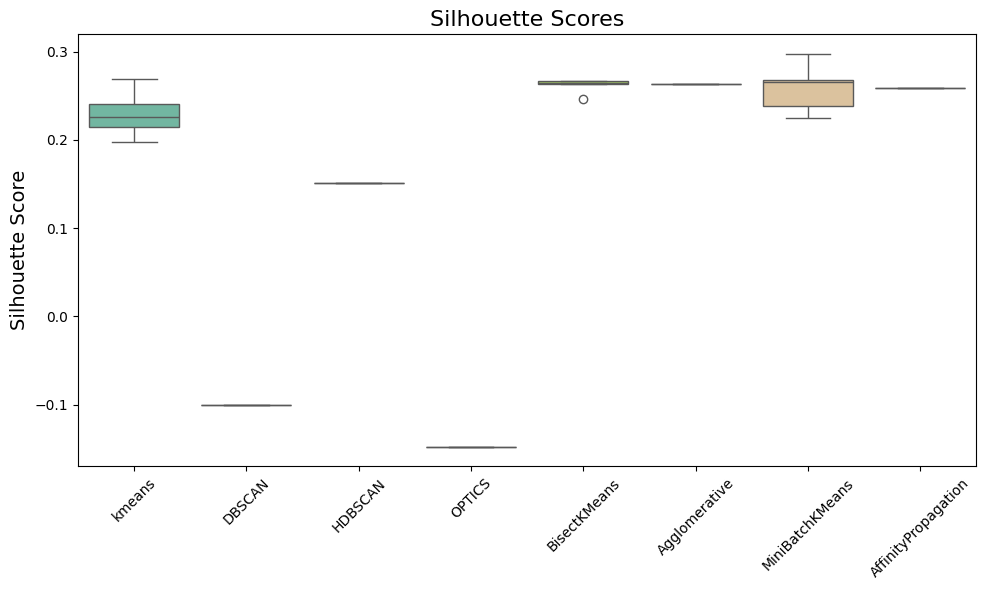

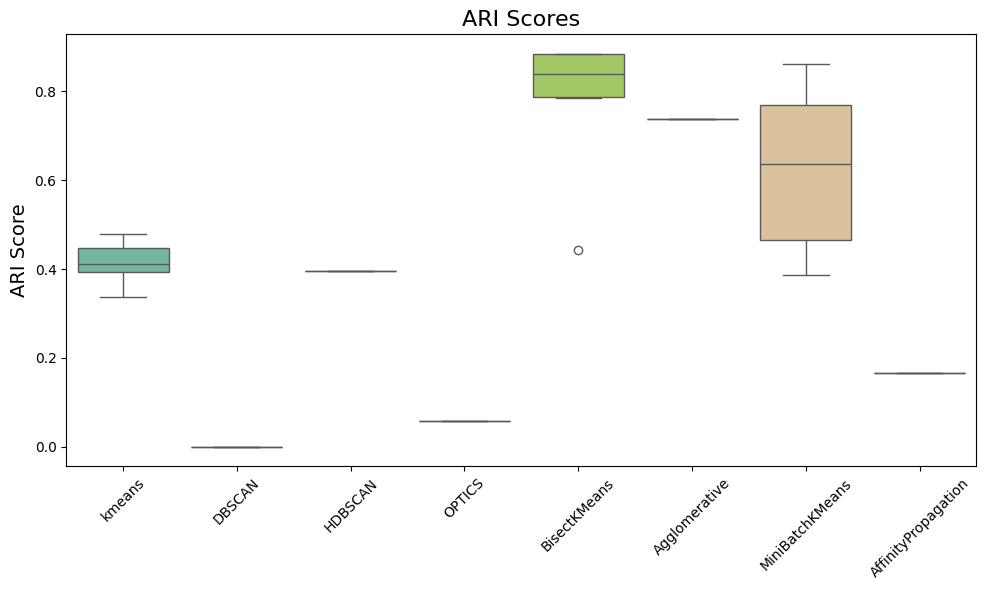

In [148]:
# Plot for Silhouette Scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=silhouette_scores, palette="Set2")
plt.title("Silhouette Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Silhouette Score", fontsize=14)
plt.tight_layout()
plt.show()

# Plot for ARI Scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=ari_scores, palette="Set2")
plt.title("ARI Scores", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("ARI Score", fontsize=14)
plt.tight_layout()
plt.show()

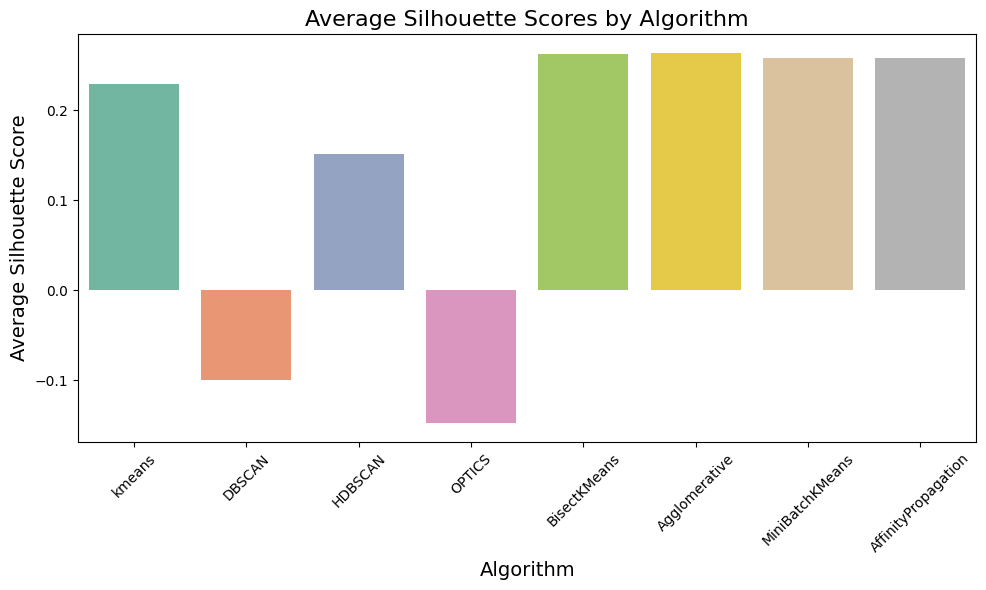

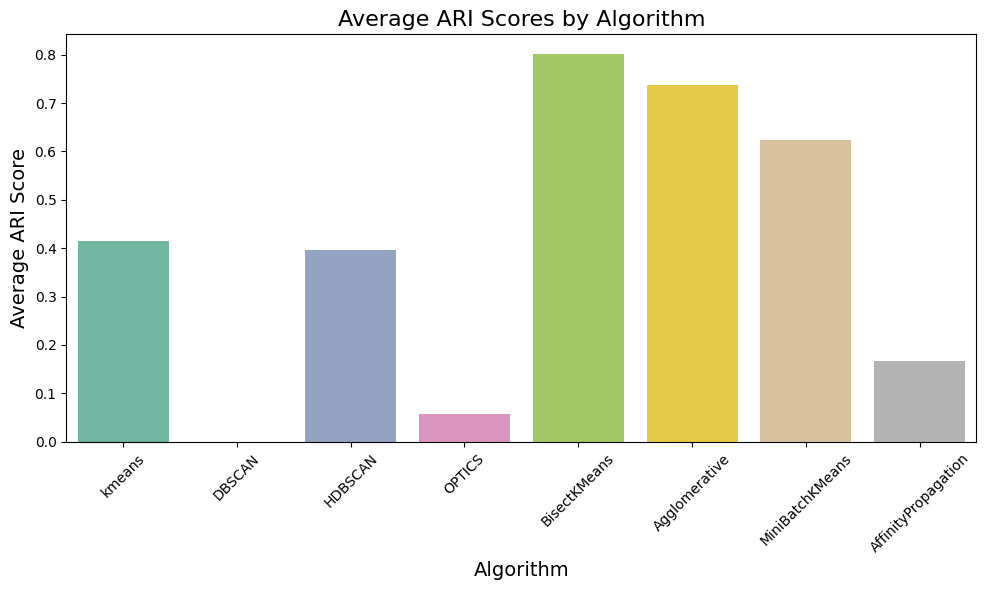

In [149]:
# Calculate averages for Silhouette Scores
silhouette_avg = {key: np.mean(values) for key, values in silhouette_scores.items()}

# Plot Silhouette Score averages
plt.figure(figsize=(10, 6))
sns.barplot(x=list(silhouette_avg.keys()), y=list(silhouette_avg.values()), palette="Set2")
plt.title("Average Silhouette Scores by Algorithm", fontsize=16)
plt.ylabel("Average Silhouette Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate averages for ARI Scores
ari_avg = {key: np.mean(values) for key, values in ari_scores.items()}

# Plot ARI Score averages
plt.figure(figsize=(10, 6))
sns.barplot(x=list(ari_avg.keys()), y=list(ari_avg.values()), palette="Set2")
plt.title("Average ARI Scores by Algorithm", fontsize=16)
plt.ylabel("Average ARI Score", fontsize=14)
plt.xlabel("Algorithm", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()